# Exploratory Data Analysis — Telco Customer Churn
**AIN-3009 MLOps Term Project**  
Abdullah Hani Abdellatif Al-Shobaki — 2284612

This notebook explores the Telco Customer Churn dataset to understand distributions, class balance, and key churn drivers.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

df = pd.read_csv('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(0.0, inplace=True)
df['Churn_num'] = (df['Churn'] == 'Yes').astype(int)
print(df.shape)
df.head()

(7043, 22)


/var/folders/gt/gj6k456d4w702px756jfwlp00000gp/T/ipykernel_82688/425367430.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(0.0, inplace=True)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_num
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1


## 1. Dataset Overview

In [2]:
print('Shape:', df.shape)
print('\nData Types:')
print(df.dtypes)
print('\nMissing values:')
print(df.isnull().sum()[df.isnull().sum() > 0])

Shape: (7043, 22)

Data Types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
Churn_num             int64
dtype: object

Missing values:
Series([], dtype: int64)


## 2. Class Distribution (Churn vs. No Churn)

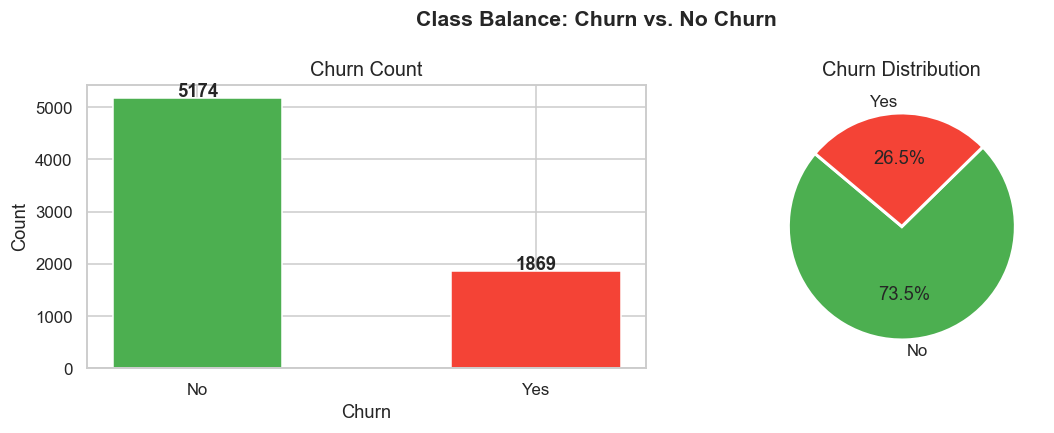

Churn rate: 26.5%


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

counts = df['Churn'].value_counts()
axes[0].bar(counts.index, counts.values, color=['#4CAF50', '#F44336'], edgecolor='white', width=0.5)
axes[0].set_title('Churn Count', fontsize=13)
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold')

pcts = counts / counts.sum() * 100
axes[1].pie(pcts, labels=pcts.index, autopct='%1.1f%%',
            colors=['#4CAF50', '#F44336'], startangle=140,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Churn Distribution', fontsize=13)

plt.suptitle('Class Balance: Churn vs. No Churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/churn_distribution.png', bbox_inches='tight')
plt.show()
print(f'Churn rate: {pcts["Yes"]:.1f}%')

## 3. Churn Rate by Contract Type

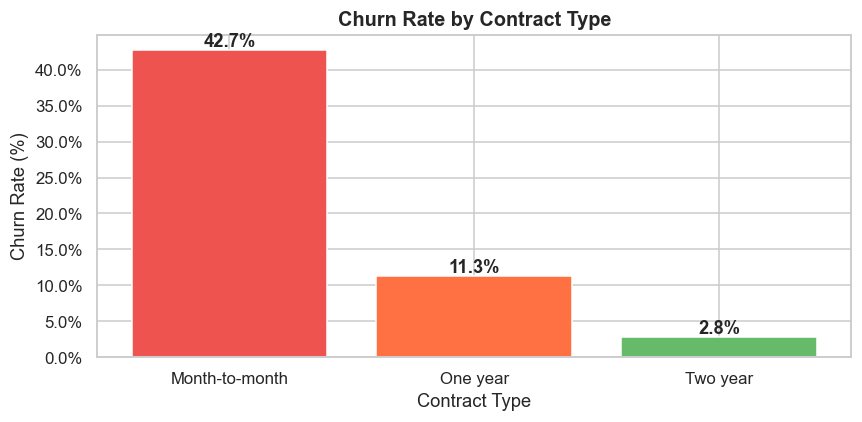

In [4]:
churn_by_contract = df.groupby('Contract')['Churn_num'].mean() * 100
churn_by_contract = churn_by_contract.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(churn_by_contract.index, churn_by_contract.values,
               color=['#EF5350', '#FF7043', '#66BB6A'], edgecolor='white')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_title('Churn Rate by Contract Type', fontsize=13, fontweight='bold')
ax.set_xlabel('Contract Type')
ax.set_ylabel('Churn Rate (%)')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('../data/churn_by_contract.png', bbox_inches='tight')
plt.show()

## 4. Churn Rate by Internet Service & Payment Method

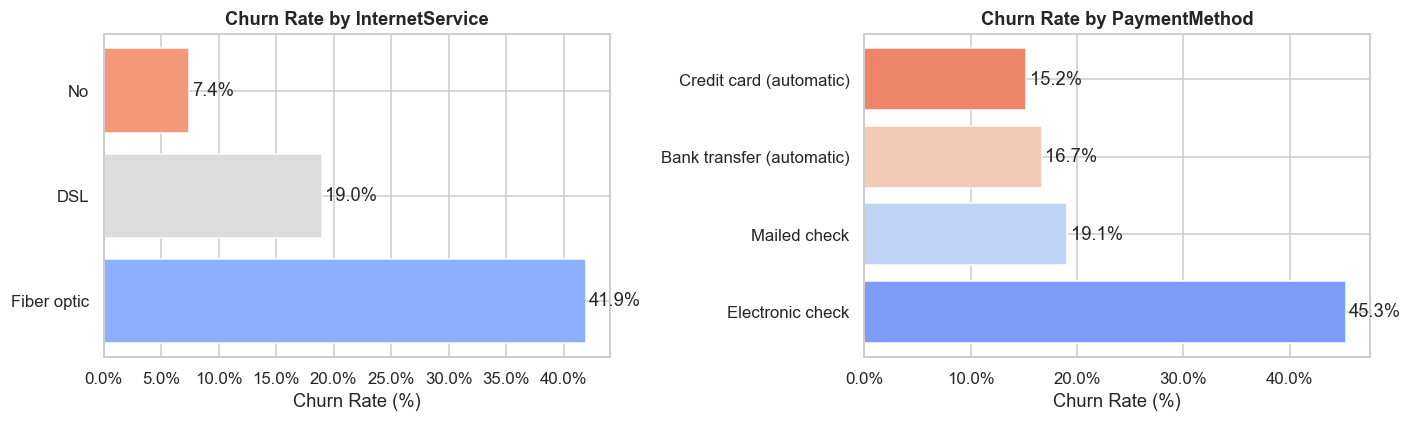

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, col in zip(axes, ['InternetService', 'PaymentMethod']):
    rates = df.groupby(col)['Churn_num'].mean().sort_values(ascending=False) * 100
    ax.barh(rates.index, rates.values, color=sns.color_palette('coolwarm', len(rates)))
    ax.xaxis.set_major_formatter(mtick.PercentFormatter())
    ax.set_title(f'Churn Rate by {col}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Churn Rate (%)')
    for i, v in enumerate(rates.values):
        ax.text(v + 0.3, i, f'{v:.1f}%', va='center')

plt.tight_layout()
plt.savefig('../data/churn_by_service_payment.png', bbox_inches='tight')
plt.show()

## 5. Numeric Feature Distributions by Churn

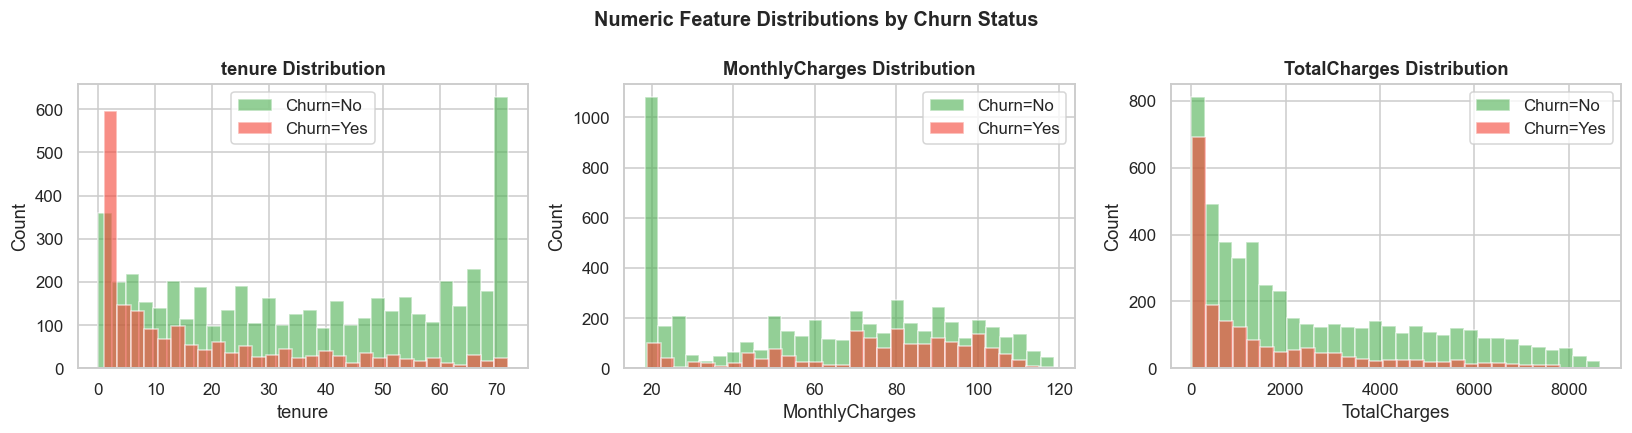

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

for ax, col in zip(axes, numeric_cols):
    for label, color in [('No', '#4CAF50'), ('Yes', '#F44336')]:
        subset = df[df['Churn'] == label][col]
        ax.hist(subset, bins=30, alpha=0.6, color=color, label=f'Churn={label}', edgecolor='white')
    ax.set_title(f'{col} Distribution', fontsize=12, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.legend()

plt.suptitle('Numeric Feature Distributions by Churn Status', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/numeric_distributions.png', bbox_inches='tight')
plt.show()

## 6. Correlation Heatmap

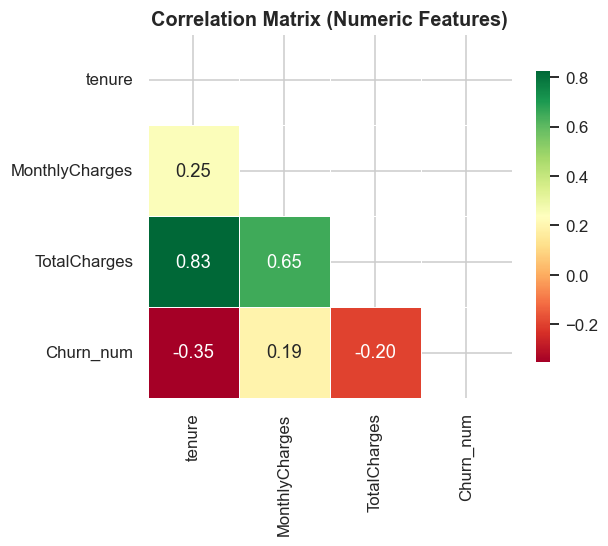

In [7]:
numeric_df = df[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn_num']].copy()

fig, ax = plt.subplots(figsize=(6, 5))
mask = np.triu(np.ones_like(numeric_df.corr(), dtype=bool))
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='RdYlGn',
            mask=mask, square=True, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Matrix (Numeric Features)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/correlation_heatmap.png', bbox_inches='tight')
plt.show()

## 7. Churn Rate by Key Binary Features

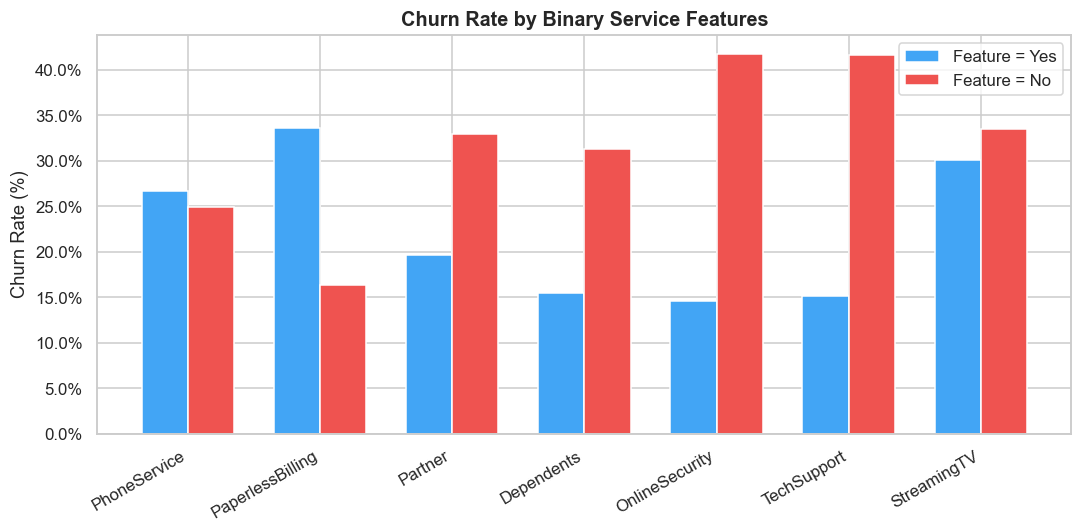

In [8]:
binary_features = ['PhoneService', 'PaperlessBilling', 'Partner', 'Dependents',
                   'OnlineSecurity', 'TechSupport', 'StreamingTV']

churn_rates = {}
for feat in binary_features:
    yes_rate = df[df[feat] == 'Yes']['Churn_num'].mean() * 100
    no_rate  = df[df[feat] == 'No']['Churn_num'].mean() * 100
    churn_rates[feat] = {'Yes': yes_rate, 'No': no_rate}

rates_df = pd.DataFrame(churn_rates).T

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(rates_df))
width = 0.35
ax.bar(x - width/2, rates_df['Yes'], width, label='Feature = Yes', color='#42A5F5')
ax.bar(x + width/2, rates_df['No'],  width, label='Feature = No',  color='#EF5350')
ax.set_xticks(x)
ax.set_xticklabels(rates_df.index, rotation=30, ha='right')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_title('Churn Rate by Binary Service Features', fontsize=13, fontweight='bold')
ax.set_ylabel('Churn Rate (%)')
ax.legend()
plt.tight_layout()
plt.savefig('../data/churn_by_binary_features.png', bbox_inches='tight')
plt.show()

## Summary of Key Findings

| Observation | Finding |
|---|---|
| Class imbalance | ~26.5% churn rate — moderate imbalance |
| Contract type | Month-to-month customers churn ~42% vs 3% for 2-year contracts |
| Tenure | Churned customers have significantly lower tenure |
| Monthly charges | Higher charges correlate with churn |
| Online security | Customers without online security churn more |
| Payment method | Electronic check users have highest churn rate |